In [55]:
import requests
from dotenv import load_dotenv
import os
import pandas as pd
import rasterio
import numpy as np
import glob
import geopandas as gpd
from rasterstats import zonal_stats

load_dotenv('../envs/dev.env')

token = os.getenv("HCDP_ADMIN_TOKEN")
local_dep_dir = os.environ.get('DEPENDENCY_DIR')

headers = {
    "Authorization": f"Bearer {token}"
}

In [ ]:
# date, startDate, endDate, island, division_type, and name. For  island, division_type, and name you can provide multiple instances of each or a comma separated list to filter by more than one (e.g. ?division_type=moku&division_type=island or  ?division_type=moku,island)
#Viewing data

url = "https://api.hcdp.ikewai.org/mesonet/climate_report/rainfall_stats"
query_params = {
    "division_type": "ahupuaa",
    "island": "Hawaiʻi",
    "name": "Alakahi",
    "date":"2026-04"
}

response = requests.get(url, params=query_params, headers=headers)

print(f"Status Code: {response.status_code}")
if response.status_code == 200:
    df_filtered = pd.DataFrame(response.json())
    display(df_filtered)
else:
    print(f"Response Text: {response.text}")

Status Code: 200


,island,division_type,name,date,mean,anomaly,pchange,rank,ytd_pnormal
0,Hawaiʻi,ahupuaa,"Ahalanui, Laepaoʻo",2026-04-01T00:00:00.000Z,7.3,0.3,4.2,46,100
1,Hawaiʻi,ahupuaa,"Alaeakila, Kaapahu",2026-04-01T00:00:00.000Z,9.9,-0.3,-2.9,45,136
2,Hawaiʻi,ahupuaa,Alakahi,2026-04-01T00:00:00.000Z,13.6,-2.3,-14.5,77,123
3,Hawaiʻi,ahupuaa,Aleamai,2026-04-01T00:00:00.000Z,10.9,-1.9,-14.7,77,122
4,Hawaiʻi,ahupuaa,"Anapuka, Hoʻopūloa",2026-04-01T00:00:00.000Z,2.5,0.9,56.1,45,308
...,...,...,...,...,...,...,...,...,...
721,Oʻahu,ahupuaa,ʻŌhikilolo,2026-04-01T00:00:00.000Z,4.6,3.1,209.3,8,352
722,Oʻahu,ahupuaa,ʻŌiʻo 1,2026-04-01T00:00:00.000Z,7.2,3.1,73.1,19,214
723,Oʻahu,ahupuaa,ʻŌiʻo 2,2026-04-01T00:00:00.000Z,6.6,2.8,73.6,20,212
724,Oʻahu,ahupuaa,ʻŌpana 1,2026-04-01T00:00:00.000Z,5.2,2.2,69.5,18,212


/var/folders/vl/70ggslts0x98b_vgphfybj140000gn/T/ipykernel_32433/4143485915.py:15: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df_filtered['date'] = pd.to_datetime(df_filtered['date']).dt.strftime('%b %Y')


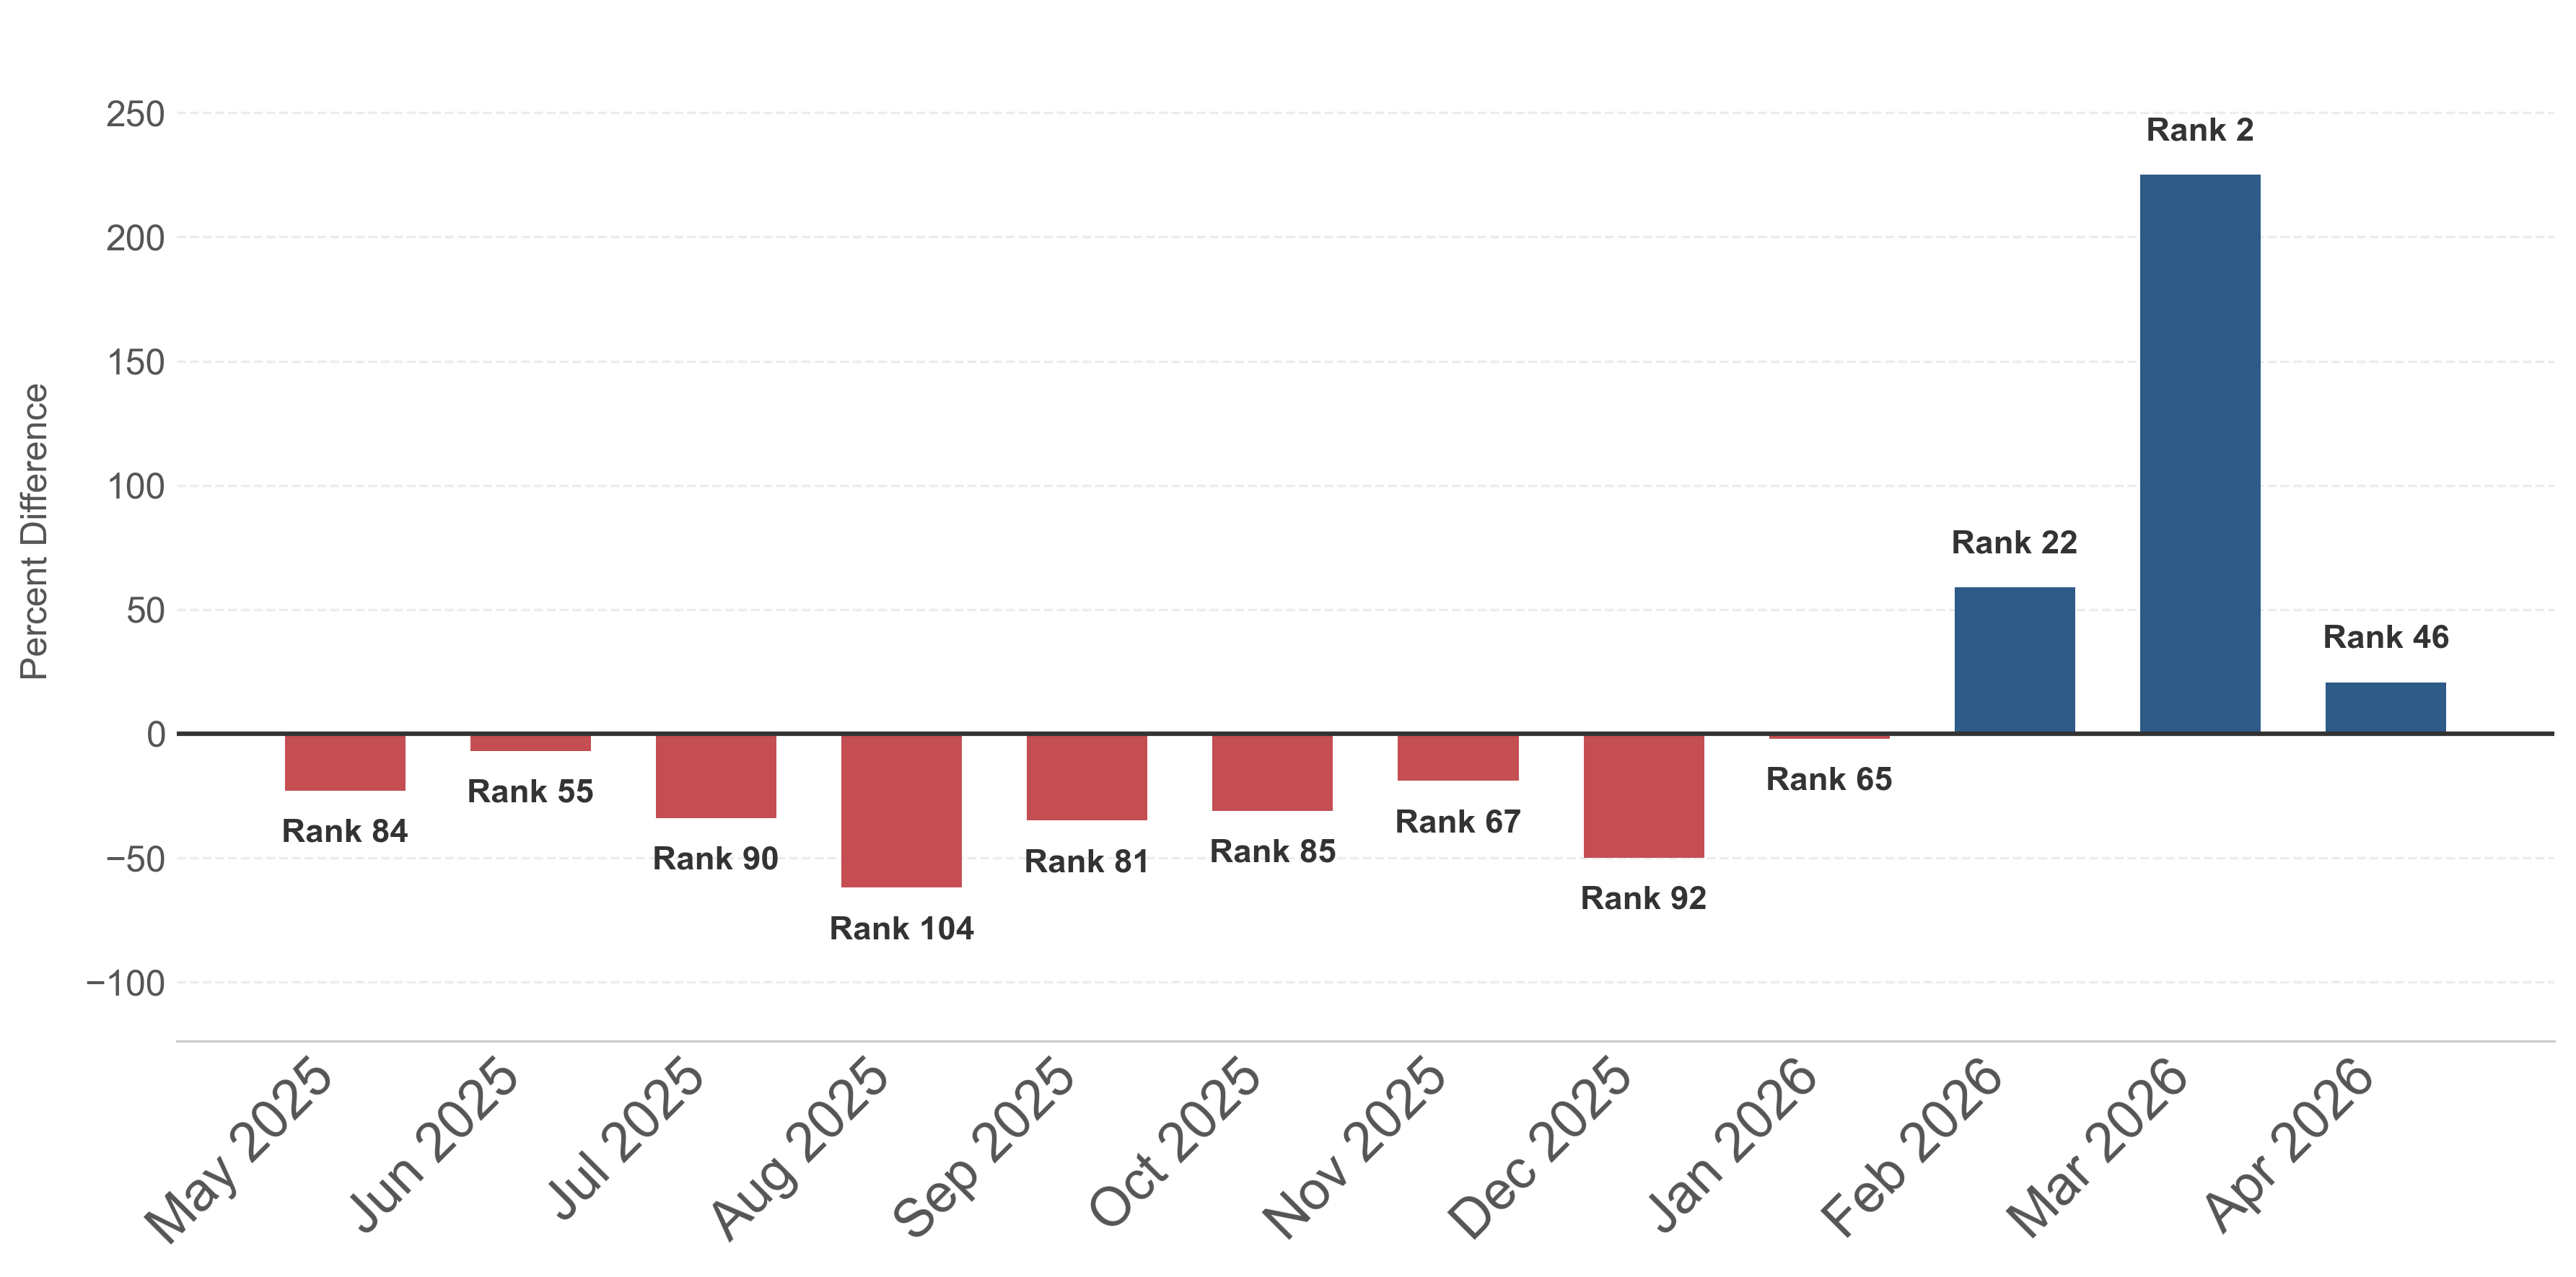

In [54]:
import pandas as pd
import matplotlib.pyplot as plt

# --- 1. SET PRESENTATION FONT & STYLE ---
# Set the font to a clean, modern sans-serif
plt.rcParams['font.family'] = 'sans-serif'
plt.rcParams['font.sans-serif'] = ['Arial', 'Helvetica', 'DejaVu Sans']

# Ensure data types are correct
df_filtered['pchange'] = pd.to_numeric(df_filtered['pchange'], errors='coerce')

# --- FIX: FORMAT THE DATES ---
# Converts the messy string to a datetime object, then formats it to "Month Year" (e.g., "May 2025")
# If you prefer "2025-05", change '%b %Y' to '%Y-%m'
df_filtered['date'] = pd.to_datetime(df_filtered['date']).dt.strftime('%b %Y')

# --- 2. SETUP HIGH-RES FIGURE ---
# Use dpi=300 for crispness in PowerPoint
fig, ax = plt.subplots(figsize=(12, 6), dpi=300)
fig.patch.set_facecolor('white') 
ax.set_facecolor('white')

# Professional color palette (Muted Blue and Red)
colors = ['#2E5B88' if val >= 0 else '#C44E52' for val in df_filtered['pchange']]

# --- 3. CREATE CHART ---
# zorder=3 ensures the bars sit in front of the gridlines
bars = ax.bar(df_filtered['date'], df_filtered['pchange'], color=colors, width=0.65, zorder=3)

# --- 4. CLEAN UP DESIGN ---
# Remove the top, right, and left bounding box lines
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['left'].set_visible(False)
ax.spines['bottom'].set_color('#CCCCCC')

# Add a subtle horizontal grid
ax.grid(axis='y', linestyle='--', alpha=0.6, color='#E0E0E0', zorder=0)

# Remove the little tick marks, but keep the text labels. Make text slightly grey.
ax.tick_params(axis='both', which='both', length=0, labelsize=12, colors='#555555')

# --- 5. ADD RANK LABELS ---
for bar, rank in zip(bars, df_filtered['rank']):
    yval = bar.get_height()
    offset = max(0.1, abs(df_filtered['pchange'].max() * 0.05))
    
    if yval >= 0:
        va = 'bottom'
        y_pos = yval + offset
    else:
        va = 'top'
        y_pos = yval - offset
        
    # Clean text formatting
    ax.text(bar.get_x() + bar.get_width() / 2, y_pos, f'Rank {rank}', 
            ha='center', va=va, fontsize=11, fontweight='bold', color='#333333')

# Draw a distinct, thin baseline at y=0 to anchor the bars
ax.axhline(0, color='#333333', linewidth=1.5, zorder=4)

# --- 6. TITLES & EXPORT ---
ax.set_ylabel('Percent Difference', fontsize=12, color='#555555', labelpad=10)

plt.xticks(rotation=45, ha='right', fontsize=18) # Keep rotation if dates are long

# Expand y-limits to give the labels room to breathe
ymin, ymax = ax.get_ylim()
ax.set_ylim(ymin - (ymax-ymin)*0.15, ymax + (ymax-ymin)*0.15)

plt.tight_layout()

# Save the file as a high-res PNG ideal for dragging into PPT
# plt.savefig('presentation_chart.png', dpi=300, bbox_inches='tight')
plt.show()

In [26]:
def convert_units(value, dataset):
  """Convert rainfall mm to inches and temperature C to F"""
  if value is None or np.isnan(value):
      return np.nan
  if dataset == "rainfall":
      return value / 25.4
  elif dataset == "temperature":
      return (value * 9/5) + 32
  return value

def make_ytd(year, month):
  input_dir = os.path.join("/Users/cherryleheu/Documents/HCDP/Data/rf_all/monthly/")
  output_dir = os.path.join("/Users/cherryleheu/Documents/HCDP/Data/rf_all/YTD/")
  first_file = os.path.join(input_dir, f"rainfall_{year}_01.tif")

  if not os.path.exists(first_file):
      print(f"Warning: Missing starting file {first_file} for YTD calculation.")
      return None

  with rasterio.open(first_file) as src:
      meta = src.meta.copy()
      first_data = src.read(1, masked=True)
      land_mask = first_data.mask
      ytd_sum = np.zeros(first_data.shape, dtype='float32')

  for m in range(1, month + 1):
      file_path = os.path.join(input_dir, f"rainfall_{year}_{m:02d}.tif")
      if os.path.exists(file_path):
          with rasterio.open(file_path) as src:
              data = src.read(1).astype('float32')
              if src.nodata is not None:
                  data[data == src.nodata] = 0
              ytd_sum += data

  ytd_sum[land_mask] = -9999
  meta.update(dtype='float32', nodata=-9999)
  output_path = os.path.join(output_dir, f'YTD_{year}_{month:02d}.tif')

  with rasterio.open(output_path, 'w', **meta) as dst:
      dst.write(ytd_sum, 1)

  return output_path

def get_statewide_stats(dataset, year, month):
  """Compute statewide mean, anomaly, percent change, and drought percentage."""
  climo_file = os.path.join(local_dep_dir, f"climo/{dataset}/{dataset}_1991-2020_{month:02d}.tif")

  print(f"\n--- Processing statewide ({dataset}) ---")

  with rasterio.open(climo_file) as src:
      clim = src.read(1).astype(float)
      clim = np.where(src.nodata == src.read(1), np.nan, clim)
      climo_mean = convert_units(np.nanmean(clim), dataset)

  all_records = []

  if dataset == "rainfall":
    tif_path = "/Users/cherryleheu/Documents/HCDP/Data/rf_all/monthly/"
    var = "rainfall"
  elif dataset == "temperature":
    tif_path = "/Users/cherryleheu/Documents/HCDP/Data/monthly/tmean/"
    var = "tmean"

  for tif in sorted(glob.glob(os.path.join(tif_path, f"{var}_*_{month:02d}.tif"))):
      parts = os.path.basename(tif).replace(".tif", "").split("_")
      curr_year, curr_month = parts[1], parts[2]
      curr_date = f"{curr_year}-{curr_month}"

      with rasterio.open(tif) as src:
          arr = src.read(1).astype(float)
          arr = np.where(arr == src.nodata, np.nan, arr)
          mean_val = convert_units(np.nanmean(arr), dataset)

          if dataset == "temperature":
              with np.errstate(all='ignore'):
                  max_val = convert_units(np.nanmax(arr), dataset)

      anomaly = mean_val - climo_mean
      pchange = ((mean_val - climo_mean) / climo_mean) * 100 if dataset == "rainfall" else anomaly

      record = {
          "date": curr_date,
          "mean": round(mean_val, 1),
          "anomaly": round(anomaly, 1),
          "pchange": int(round(pchange, 0)),
      }
      if dataset == "temperature":
          record["max"] = int(round(max_val, 0))

      all_records.append(record)

  df = pd.DataFrame(all_records)

  df["rank"] = df["anomaly"].rank(method="min", ascending=False)
  latest = df[df["date"] == f"{year}-{month:02d}"].copy()
  if latest.empty:
      print(f"No data found for {year}-{month:02d}")
      return

  if dataset == "rainfall":
      current_ytd_path = make_ytd(year, month)
      climo_ytd_path = os.path.join(local_dep_dir, "climo", "rainfall_ytd", f"YTD_rain_month_{month:02d}.tif")

      with rasterio.open(current_ytd_path) as src:
          curr_arr = src.read(1).astype(float)
          curr_arr = np.where(curr_arr == -9999, np.nan, curr_arr)
          curr_mean = np.nanmean(curr_arr)

      with rasterio.open(climo_ytd_path) as src:
          climo_arr = src.read(1).astype(float)
          climo_arr = np.where(climo_arr == -9999, np.nan, climo_arr)
          climo_mean = np.nanmean(climo_arr)

      if not np.isnan(curr_mean) and not np.isnan(climo_mean) and climo_mean != 0:
          pnormal = (curr_mean / climo_mean) * 100
      else:
          pnormal = np.nan

      latest["ytd_pnormal"] = int(round(pnormal, 0))

  latest["island"] = "Statewide"
  latest["division_type"] = "Statewide"
  latest["name"] = "Statewide"

  base_cols = ["island", "division_type", "name", "date", "mean", "anomaly", "pchange", "rank"]

  if dataset == "rainfall":
      base_cols.append("ytd_pnormal")
  elif dataset == "temperature":
      base_cols.append("max")

  result_list = [x.item() if hasattr(x, 'item') else x for x in latest[base_cols].iloc[0].tolist()]

  print(f"Returning stats for {year}-{month:02d}: {result_list}")
  return result_list


In [29]:
def get_stats(division, dataset, year, month):
  """Compute rainfall or temperature statistics for a island or division shapefile."""
  print(f"\n--- Processing {division} - {dataset} ---")

  shapefile = os.path.join(local_dep_dir, f"shapefiles/{division}.shp")
  climo_file = os.path.join(local_dep_dir, f"climo/{dataset}/{dataset}_1991-2020_{month:02d}.tif")

  gdf = gpd.read_file(shapefile).copy()

  island_col = next((c for c in gdf.columns if c.lower() in ["island", "mokupuni", "isle", "islandname"]), None)
  name_col = next((c for c in gdf.columns if c.lower() in ["name", "division", "moku", "climate_div", "ahupuaa", "county", "name_hwn"]), None)

  gdf['geometry'] = gdf['geometry'].simplify(tolerance=0.001, preserve_topology=True)

  if island_col and name_col:
      # Standard logic for complex shapefiles (moku, ahupuaa)
      is_same_island_dup = gdf.duplicated(subset=[island_col, name_col], keep=False)
      cum_count = gdf.groupby([island_col, name_col]).cumcount() + 1
      gdf.loc[is_same_island_dup, name_col] = (
          gdf.loc[is_same_island_dup, name_col].astype(str) + " " + cum_count[is_same_island_dup].astype(str)
      )
      gdf = gdf.dissolve(by=[island_col, name_col], as_index=False)
      gdf["island_clean"] = gdf[island_col]
      gdf["name_clean"] = gdf[name_col]
  elif name_col:
      gdf = gdf.dissolve(by=name_col, as_index=False)
      gdf["name_clean"] = gdf[name_col]

      if division == "island":
          gdf["island_clean"] = gdf[name_col]
      else:
          gdf["island_clean"] = "Statewide"

  gdf["division_type"] = division

  climo_zs = zonal_stats(vectors=gdf, raster=climo_file, stats=["mean"], nodata=None)
  gdf["climo_mean"] = [convert_units(c["mean"], dataset) for c in climo_zs]

  all_records = []

  if dataset == "rainfall":
      tif_path = "/Users/cherryleheu/Documents/HCDP/Data/rf_all/monthly/"
      var = "rainfall"
  elif dataset == "temperature":
      tif_path = "/Users/cherryleheu/Documents/HCDP/Data/monthly/tmean/"
      var = "tmean"

  for tif in sorted(glob.glob(os.path.join(tif_path, f"{var}_*_{month:02d}.tif"))):
      parts = os.path.basename(tif).replace(".tif", "").split("_")
      curr_year, curr_month = parts[1], parts[2]
      curr_date = f"{curr_year}-{curr_month}"

      stats_to_compute = ["mean", "max"] if dataset == "temperature" else ["mean"]
      stats = zonal_stats(vectors=gdf, raster=tif, stats=stats_to_compute, nodata=None)

      for idx, row in gdf.iterrows():
          mean_raw = stats[idx]["mean"]

          if mean_raw is None or np.isnan(mean_raw):
              mean_val, anomaly, pchange = np.nan, np.nan, np.nan
              if dataset == "temperature":
                  max_val = np.nan
          else:
              mean_val = convert_units(mean_raw, dataset)
              climo_mean = row["climo_mean"]
              if np.isnan(climo_mean):
                  anomaly, pchange = np.nan, np.nan
              else:
                  anomaly = mean_val - climo_mean
                  pchange = ((mean_val - climo_mean) / climo_mean) * 100 if dataset == "rainfall" else anomaly

              if dataset == "temperature":
                  max_raw = stats[idx].get("max")
                  max_val = convert_units(max_raw, dataset) if max_raw is not None else np.nan

          record = {
              "island": row["island_clean"],
              "division_type": row["division_type"],
              "name": row["name_clean"],
              "date": curr_date,
              "mean": round(mean_val, 1) if not np.isnan(mean_val) else np.nan,
              "anomaly": round(anomaly, 1) if not np.isnan(anomaly) else np.nan,
              "pchange": round(pchange, 1) if not np.isnan(pchange) else np.nan,
          }
          if dataset == "temperature":
              record["max"] = round(max_val, 0) if not np.isnan(max_val) else np.nan
                  
          all_records.append(record)

  df = pd.DataFrame(all_records)

  # Rank anomalies across the historical record
  df["rank"] = df.groupby(["island", "name"])["anomaly"].rank(method="min", ascending=False)
      
  # Filter down to the specific requested month/year
  latest_df = df[df["date"] == f"{year}-{month:02d}"].reset_index(drop=True)

  if dataset == "rainfall":
      current_ytd_path = make_ytd(year, month)
      climo_ytd_path = os.path.join(local_dep_dir, "climo", "rainfall_ytd", f"YTD_rain_month_{month:02d}.tif")

      current_ytd_zs = zonal_stats(vectors=gdf, raster=current_ytd_path, stats=["mean"], nodata=-9999)
      climo_ytd_zs = zonal_stats(vectors=gdf, raster=climo_ytd_path, stats=["mean"], nodata=-9999)

      ytd_pnormals = []
      for curr, climo in zip(current_ytd_zs, climo_ytd_zs):
          curr_mean = curr['mean']
          climo_mean = climo['mean']

          if curr_mean is not None and climo_mean is not None and climo_mean != 0:
              pnormal = round((curr_mean / climo_mean) * 100, 0)
          else:
              pnormal = np.nan

          ytd_pnormals.append(pnormal)
              
      # FIXED: Assign the entire list back to the dataframe column 
      latest_df["ytd_pnormal"] = ytd_pnormals

  base_cols = ["island", "division_type", "name", "date", "mean", "anomaly", "pchange", "rank"]

  if dataset == "rainfall":
      base_cols.append("ytd_pnormal")
  elif dataset == "temperature":
      base_cols.append("max")

  # Filter columns to exact required order
  latest_df = latest_df[base_cols]
      
  # Replace NaN with None for valid JSON serialization
  latest_df = latest_df.replace({np.nan: None})
      
  # Convert dataframe to 2D list of lists
  final_data = latest_df.values.tolist()

  print(f"Returning stats for {len(final_data)} locations for {year}-{month:02d}")
  return final_data

In [32]:
import requests

dataset = "temperature"
url = f"https://api.hcdp.ikewai.org/mesonet/climate_report/{dataset}_stats"

start_year = 1990
end_year = 2026
current_month_limit = 3

failed_requests = []

for year in range(start_year, end_year + 1):
  data_list = []
  last_month = current_month_limit if year == end_year else 12

  for month in range(1, last_month + 1):
      rows = get_statewide_stats(dataset, year, month)
      data_list.append(rows)

  payload = {
      "overwrite": True,
      "data": data_list
  }

  response = requests.post(
      url,
      json=payload,
      headers=headers
  )

  print(response.status_code)
  print(response.text)

  if response.status_code != 200:
    print(response.text)
    # Append the failure details to our tracking list
    failed_requests.append({
        "date": f"{year}-{month:02d}",
        "status_code": response.status_code,
        "error": response.text.strip()
    })
print("\n" + "="*50)
print("EXECUTION SUMMARY")
print("="*50)

if failed_requests:
    print(f"Total Failed Requests (!= 200): {len(failed_requests)}")
    for failure in failed_requests:
        print(f"Date: {failure['date']} | Status: {failure['status_code']} | Error: {failure['error']}")
else:
    print("All requests completed successfully with status 200!")


--- Processing statewide (temperature) ---
Returning stats for 1990-01: ['Statewide', 'Statewide', 'Statewide', '1990-01', 63.4, 0.0, 0, 20.0, 74]

--- Processing statewide (temperature) ---
Returning stats for 1990-02: ['Statewide', 'Statewide', 'Statewide', '1990-02', 61.3, -1.8, -2, 36.0, 72]

--- Processing statewide (temperature) ---
Returning stats for 1990-03: ['Statewide', 'Statewide', 'Statewide', '1990-03', 62.4, -1.1, -1, 31.0, 72]

--- Processing statewide (temperature) ---
Returning stats for 1990-04: ['Statewide', 'Statewide', 'Statewide', '1990-04', 64.9, 0.1, 0, 18.0, 75]

--- Processing statewide (temperature) ---
Returning stats for 1990-05: ['Statewide', 'Statewide', 'Statewide', '1990-05', 65.6, -0.6, -1, 26.0, 76]

--- Processing statewide (temperature) ---
Returning stats for 1990-06: ['Statewide', 'Statewide', 'Statewide', '1990-06', 67.4, -0.4, 0, 25.0, 78]

--- Processing statewide (temperature) ---
Returning stats for 1990-07: ['Statewide', 'Statewide', 'Stat

In [6]:
import requests

dataset = "rainfall"
url = f"https://api.hcdp.ikewai.org/mesonet/climate_report/{dataset}_stats"

start_year = 1920
end_year = 2026
current_month_limit = 3

# Make sure headers is defined, e.g.:
# headers = {"Content-Type": "application/json", "Authorization": "Bearer YOUR_TOKEN"}

for year in range(start_year, end_year + 1):
    last_month = current_month_limit if year == end_year else 12
    
    for month in range(1, last_month + 1):
        stats = get_stats("island", dataset, year, month)
        
        # Adapt payload to be exactly the stats object
        # Using .copy() to avoid modifying the original dict if it's referenced elsewhere
        payload = stats.copy() if isinstance(stats, dict) else stats
        
        # Inject the overwrite flag directly into the top level of the stats dictionary
        if isinstance(payload, dict):
            payload["overwrite"] = True
            
        # Send the request individually for each month
        response = requests.post(url, json=payload, headers=headers)
        
        # Optional: Print out the month as well to track granular progress
        print(f"Status Code: {response.status_code} for {year}-{month:02d}")
        
        # Consider adding a small delay if the API has strict rate limits
        # import time; time.sleep(0.1)


--- Processing island - rainfall ---
Returning stats for 7 locations for 1920-01

--- Processing island - rainfall ---
Returning stats for 7 locations for 1920-02

--- Processing island - rainfall ---
Returning stats for 7 locations for 1920-03

--- Processing island - rainfall ---
Returning stats for 7 locations for 1920-04

--- Processing island - rainfall ---
Returning stats for 7 locations for 1920-05

--- Processing island - rainfall ---
Returning stats for 7 locations for 1920-06

--- Processing island - rainfall ---
Returning stats for 7 locations for 1920-07

--- Processing island - rainfall ---
Returning stats for 7 locations for 1920-08

--- Processing island - rainfall ---
Returning stats for 7 locations for 1920-09

--- Processing island - rainfall ---
Returning stats for 7 locations for 1920-10

--- Processing island - rainfall ---
Returning stats for 7 locations for 1920-11

--- Processing island - rainfall ---
Returning stats for 7 locations for 1920-12
Status Code: 400

KeyboardInterrupt: 

In [ ]:

url = "https://api.hcdp.ikewai.org/mesonet/climate_report/rainfall_stats"

# const STAT_TABLE_DATA = {
#   rainfall_stats: ['Statewide', 'Statewide', 'Statewide', 'date', 'mean', 'anomaly', 'pchange', 'rank', 'ytd_pnormal'],
#   temperature_stats: ['Statewide', 'Statewide', 'Statewide', 'date', 'mean', 'anomaly', 'pchange', 'rank', 'max'],
#   drought_stats: ['division_full', 'date', 'd4', 'd3', 'd2', 'd1', 'd0', 'near_normal', 'w0', 'w1', 'w2', 'w3', 'w4'],
#   rainfall_historical: ['division_full', 'date', 'value'],
#   temperature_historical: ['division_full', 'date', 'value']
# };

payload = {
    "overwrite": True,
    "data": [
      get_statewide_stats("rainfall", 2026, 3)
    ]
}

response = requests.post(url, json=payload, headers=headers)

# 4. Print the result to see if it worked
print(f"Status Code: {response.status_code}")
print(f"Response Text: {response.text}")


--- Processing statewide (rainfall) ---
Returning stats for 2026-03: ['Statewide', 'Statewide', 'Statewide', '2026-03', np.float64(22.289707995859303), np.float64(15.436666994520824), np.float64(225.25280370430974), np.float64(2.0), np.float64(206.9470762479052)]
Status Code: 200
Response Text: {"modified":1}


In [18]:
def get_drought_stats(division, year, month):
    """Compute percentage of pixels in each SPI category for divisions."""
    print(f"\n--- Processing {division} - drought ---")

    shapefile = os.path.join(local_dep_dir, f"shapefiles/{division}.shp")
    tif_path = os.path.join(local_dep_dir, "spi3", "cat", f"spi3_cat_{year}_{month:02d}.tif") 

    if not os.path.exists(tif_path):
        print(f"Warning: Missing drought file {tif_path}")
        return None

    cat_map = {
        0: "D4", 1: "D3", 2: "D2", 3: "D1", 4: "D0",
        5: "Near Normal",
        6: "W0", 7: "W1", 8: "W2", 9: "W3", 10: "W4"
    }

    gdf = gpd.read_file(shapefile).copy()
    island_col = next((c for c in gdf.columns if c.lower() in ["island", "mokupuni", "isle", "islandname"]), None)
    name_col = next((c for c in gdf.columns if c.lower() in ["name", "division", "moku", "climate_div", "ahupuaa", "county", "name_hwn"]), None)

    gdf['geometry'] = gdf['geometry'].simplify(tolerance=0.001, preserve_topology=True)

    if island_col and name_col:
        is_same_island_dup = gdf.duplicated(subset=[island_col, name_col], keep=False)
        cum_count = gdf.groupby([island_col, name_col]).cumcount() + 1
        gdf.loc[is_same_island_dup, name_col] = (
            gdf.loc[is_same_island_dup, name_col].astype(str) + " " + cum_count[is_same_island_dup].astype(str)
        )
        gdf = gdf.dissolve(by=[island_col, name_col], as_index=False)
        gdf["island_clean"] = gdf[island_col]
        gdf["name_clean"] = gdf[name_col]
    elif name_col:
        gdf = gdf.dissolve(by=name_col, as_index=False)
        gdf["name_clean"] = gdf[name_col]

        if division == "island":
            gdf["island_clean"] = gdf[name_col]
        else:
            gdf["island_clean"] = "Statewide"

    gdf["division_type"] = division

    with rasterio.open(tif_path) as src:
        nodata = src.nodata

    zs = zonal_stats(gdf, tif_path, categorical=True, nodata=nodata)

    all_records = []
    for i, stats in enumerate(zs):
        row = gdf.iloc[i]
        total = sum(stats.values()) if stats else 0

        record = {
            "island": row["island_clean"],
            "division_type": row["division_type"],
            "name": row["name_clean"],
            "date": f"{year}-{month:02d}",
        }

        for val, code in cat_map.items():
            count = stats.get(val, 0) if stats else 0
            # Rounding to 2 decimals to keep the payload clean
            pct = round((count / total) * 100, 2) if total > 0 else np.nan
            record[code] = pct

        all_records.append(record)

    # Use the DataFrame to extract ALL rows in the correct column order
    df = pd.DataFrame(all_records)
    
    drought_cols = [
        "island", "division_type", "name", "date", 
        "D4", "D3", "D2", "D1", "D0",
        "Near Normal", 
        "W0", "W1", "W2", "W3", "W4"
    ]
    
    # Filter columns
    df = df[drought_cols]
    
    # Replace NaN with None so JSON serialization parses it properly as null
    df = df.replace({np.nan: None})
    
    # Convert the entire dataframe to a list of lists (2D array)
    result_list = df.values.tolist()

    print(f"Returning {len(result_list)} stats records for {year}-{month:02d}")
    return result_list

In [20]:
year = 1990
month = 4
stats = get_drought_stats("island", year, month)




--- Processing island - drought ---
Returning 7 stats records for 1990-04
Status Code: 200 for 1990-04


In [22]:
import requests

dataset = "drought"
url = f"https://api.hcdp.ikewai.org/mesonet/climate_report/{dataset}_stats"

start_year = 1990
end_year = 2026
current_month_limit = 3

# Initialize a list to keep track of any failed requests
failed_requests = []

for year in range(start_year, end_year + 1):
    last_month = current_month_limit if year == end_year else 12
    
    for month in range(1, last_month + 1):
        stats = get_drought_stats("island", year, month)
        
        if stats: 
            payload = {
                "overwrite": True,
                "data": stats 
            }
                        
            response = requests.post(url, json=payload, headers=headers)
                    
            print(f"Status Code: {response.status_code} for {year}-{month:02d}")
            
            if response.status_code != 200:
                print(response.text)
                # Append the failure details to our tracking list
                failed_requests.append({
                    "date": f"{year}-{month:02d}",
                    "status_code": response.status_code,
                    "error": response.text.strip()
                })
        else:
            print(f"No data generated for {year}-{month:02d}")

print("\n" + "="*50)
print("EXECUTION SUMMARY")
print("="*50)

if failed_requests:
    print(f"Total Failed Requests (!= 200): {len(failed_requests)}")
    for failure in failed_requests:
        print(f"Date: {failure['date']} | Status: {failure['status_code']} | Error: {failure['error']}")
else:
    print("All requests completed successfully with status 200!")


--- Processing island - drought ---
No data generated for 1990-01

--- Processing island - drought ---
No data generated for 1990-02

--- Processing island - drought ---
Returning 7 stats records for 1990-03
Status Code: 200 for 1990-03

--- Processing island - drought ---
Returning 7 stats records for 1990-04
Status Code: 200 for 1990-04

--- Processing island - drought ---
Returning 7 stats records for 1990-05
Status Code: 200 for 1990-05

--- Processing island - drought ---
Returning 7 stats records for 1990-06
Status Code: 200 for 1990-06

--- Processing island - drought ---
Returning 7 stats records for 1990-07
Status Code: 200 for 1990-07

--- Processing island - drought ---
Returning 7 stats records for 1990-08
Status Code: 200 for 1990-08

--- Processing island - drought ---
Returning 7 stats records for 1990-09
Status Code: 200 for 1990-09

--- Processing island - drought ---
Returning 7 stats records for 1990-10
Status Code: 200 for 1990-10

--- Processing island - drought -

In [23]:
def get_statewide_drought_stats(year, month):
  """Compute statewide drought category percentages."""
  print(f"\n--- Processing statewide (drought) {year}-{month:02d} ---")

  # Assuming your tif path updates dynamically based on year/month. 
  # If the filename changes per month, make sure to update this string!
  tif_path = os.path.join(local_dep_dir, "spi3", "cat", f"spi3_cat_{year}_{month:02d}.tif") 
      
  if not os.path.exists(tif_path):
      print(f"Warning: Missing drought file {tif_path}")
      return None

  cat_map = {
      0: "D4", 1: "D3", 2: "D2", 3: "D1", 4: "D0",
      5: "Near Normal",
      6: "W0", 7: "W1", 8: "W2", 9: "W3", 10: "W4"
  }

  with rasterio.open(tif_path) as src:
      data = src.read(1)
      nodata = src.nodata

  valid_mask = (data != nodata)
  valid_data = data[valid_mask]
  total_pixels = valid_data.size

  # Build the record dictionary
  record = {
      "island": "Statewide",
      "division_type": "Statewide",
      "name": "Statewide",
      "date": f"{year}-{month:02d}"
  }

  if total_pixels > 0:
      unique, counts = np.unique(valid_data, return_counts=True)
      counts_dict = dict(zip(unique, counts))

      for val, code in cat_map.items():
          count = counts_dict.get(val, 0)
          # Rounding to 2 decimal places for cleaner JSON payload
          record[code] = round((count / total_pixels) * 100, 2)
  else:
      for val, code in cat_map.items():
          record[code] = np.nan

  # Define the exact column order expected by your API/Database
  drought_cols = [
      "island", "division_type", "name", "date",
      "D4", "D3", "D2", "D1", "D0",
      "Near Normal",
      "W0", "W1", "W2", "W3", "W4"
  ]

  # Extract values in the exact order
  result_list = [record[col] for col in drought_cols]
      
  # Convert any numpy types (like np.float64) to native Python types for JSON
  result_list = [x.item() if hasattr(x, 'item') else x for x in result_list]

  print(f"Returning stats for {year}-{month:02d}: {result_list}")
  return result_list

In [24]:
url = f"https://api.hcdp.ikewai.org/mesonet/climate_report/drought_stats"

start_year = 1990
end_year = 2026
current_month_limit = 3

for year in range(start_year, end_year + 1):
    data_list = []
    last_month = current_month_limit if year == end_year else 12

    for month in range(1, last_month + 1):
        row_data = get_statewide_drought_stats(year, month)
      
        if row_data:
            data_list.append(row_data) 

    if data_list:
        payload = {
            "overwrite": True,
            "data": data_list
        }
        response = requests.post(
            url,
            json=payload,
            headers=headers # Ensure 'headers' is defined in your environment
        )

        print(f"Year {year} Status: {response.status_code}")
        if response.status_code != 200:
            print(response.text)


--- Processing statewide (drought) 1990-01 ---

--- Processing statewide (drought) 1990-02 ---

--- Processing statewide (drought) 1990-03 ---
Returning stats for 1990-03: ['Statewide', 'Statewide', 'Statewide', '1990-03', 0.0, 0.0, 0.0, 0.0, 0.0, 0.59, 3.87, 27.22, 40.62, 21.17, 6.54]

--- Processing statewide (drought) 1990-04 ---
Returning stats for 1990-04: ['Statewide', 'Statewide', 'Statewide', '1990-04', 0.0, 0.0, 0.0, 0.0, 0.43, 55.26, 18.06, 17.78, 5.28, 2.55, 0.64]

--- Processing statewide (drought) 1990-05 ---
Returning stats for 1990-05: ['Statewide', 'Statewide', 'Statewide', '1990-05', 0.0, 0.18, 1.16, 17.86, 18.9, 58.72, 1.73, 1.16, 0.24, 0.05, 0.0]

--- Processing statewide (drought) 1990-06 ---
Returning stats for 1990-06: ['Statewide', 'Statewide', 'Statewide', '1990-06', 0.7, 5.34, 8.6, 26.84, 15.11, 39.67, 2.36, 1.06, 0.15, 0.08, 0.1]

--- Processing statewide (drought) 1990-07 ---
Returning stats for 1990-07: ['Statewide', 'Statewide', 'Statewide', '1990-07', 1.0